In [9]:
from pathlib import Path
import sys
import os
import glob
from itertools import chain

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Make src/ imports work when running from repo root or notebooks/
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "src"))

from colliderml_electron.io import prompt_electrons, descendant_pids
from colliderml_electron.coords import xyz_to_eta_phi, momentum_to_eta_phi, delta_eta_phi
from colliderml_electron.calibration import calibrate

# -----------------------
# User settings
# -----------------------

CHANNEL = "zee"
PILEUP = "pu200"

MAX_EVENTS = 20

# DBSCAN settings to sweep
EPS_VALUES = [0.04, 0.06, 0.08, 0.10]
MIN_SAMPLES = 2

# Large search cone around the truth electron.
# DBSCAN runs only on cells inside this candidate region.
CANDIDATE_DR = 0.4

# Optional fixed ΔR comparison values.
# These are not exactly your old training method, because here we apply
# fixed ΔR to all nearby event cells so that contamination can be measured.
FIXED_DR_VALUES = [0.05, 0.08, 0.10, 0.15, 0.20]

# "full" = electron + descendants.
# "direct" = only the prompt electron particle_id.
TRUTH_MODE = "full"

OUT_DIR = REPO_ROOT / "results" / "cluster_purity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Output directory:", OUT_DIR)

Repo root: /Users/loiclambert/code/colliderml-electron-calo
Output directory: /Users/loiclambert/code/colliderml-electron-calo/results/cluster_purity


In [21]:
def analyze_dbscan_groups_one_electron(
    particles_row: dict,
    calo_row: dict,
    electron: dict,
    eps: float,
    min_samples: int = 2,
    candidate_dR: float = 0.25,
    group_input_mode: str = "nearby_all",
    truth_mode: str = "full",
):
    """
    Fast DBSCAN group-count analysis.

    group_input_mode:
        "nearby_all"    = cluster all event calo hits within candidate_dR of electron direction
        "truth_family"  = cluster only electron + descendant calo hits

    Outputs:
        n_clusters
        n_noise_hits
        largest_cluster_n_hits
        chosen_cluster_n_hits
        cluster_sizes
    """

    x = np.asarray(calo_row["x"], dtype=np.float32)
    y = np.asarray(calo_row["y"], dtype=np.float32)
    z = np.asarray(calo_row["z"], dtype=np.float32)
    e_total_raw = np.asarray(calo_row["total_energy"], dtype=np.float32)

    eta_c, phi_c = xyz_to_eta_phi(x, y, z)
    eta_c = np.asarray(eta_c, dtype=np.float32)
    phi_c = np.asarray(phi_c, dtype=np.float32)

    eta_e, phi_e = momentum_to_eta_phi(
        electron["px"],
        electron["py"],
        electron["pz"],
    )

    eta_e = float(eta_e)
    phi_e = float(phi_e)

    deta, dphi = delta_eta_phi(eta_c, phi_c, eta_e, phi_e)
    dR = np.sqrt(deta**2 + dphi**2)

    if group_input_mode == "nearby_all":
        candidate_idx = np.where(dR <= candidate_dR)[0]

    elif group_input_mode == "truth_family":
        target_pids = get_target_pids(particles_row, electron, truth_mode=truth_mode)
        target_e_raw = target_energy_per_cell(calo_row, target_pids)
        candidate_idx = np.where(target_e_raw > 0)[0]

    else:
        raise ValueError(f"Unknown group_input_mode: {group_input_mode}")

    base = {
        "event_id": int(particles_row["event_id"]),
        "particle_id": int(electron["particle_id"]),
        "truth_energy": float(electron["energy"]),
        "truth_eta": eta_e,
        "truth_phi": phi_e,
        "eps": float(eps),
        "min_samples": int(min_samples),
        "candidate_dR": float(candidate_dR),
        "group_input_mode": group_input_mode,
        "n_input_hits": int(len(candidate_idx)),
    }

    if len(candidate_idx) < min_samples:
        return {
            **base,
            "matched": False,
            "failure_reason": "too_few_input_hits",
            "n_clusters": 0,
            "n_noise_hits": int(len(candidate_idx)),
            "noise_fraction": 1.0 if len(candidate_idx) > 0 else np.nan,
            "largest_cluster_n_hits": 0,
            "chosen_cluster_n_hits": 0,
            "largest_cluster_energy": 0.0,
            "chosen_cluster_energy": 0.0,
            "cluster_sizes": [],
        }

    X = np.column_stack([deta[candidate_idx], dphi[candidate_idx]])

    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean",
    ).fit_predict(X)

    cluster_labels = sorted(set(labels[labels >= 0]))
    n_clusters = len(cluster_labels)
    n_noise_hits = int((labels == -1).sum())

    if n_clusters == 0:
        return {
            **base,
            "matched": False,
            "failure_reason": "dbscan_found_no_clusters",
            "n_clusters": 0,
            "n_noise_hits": n_noise_hits,
            "noise_fraction": safe_div(n_noise_hits, len(candidate_idx)),
            "largest_cluster_n_hits": 0,
            "chosen_cluster_n_hits": 0,
            "largest_cluster_energy": 0.0,
            "chosen_cluster_energy": 0.0,
            "cluster_sizes": [],
        }

    cluster_sizes = []
    cluster_energies = []

    for lab in cluster_labels:
        local_mask = labels == lab
        global_idx = candidate_idx[local_mask]

        cluster_sizes.append(int(local_mask.sum()))
        cluster_energies.append(
            float(
                calibrate(
                    e_total_raw[global_idx],
                    x[global_idx],
                    y[global_idx],
                    z[global_idx],
                ).sum()
            )
        )

    largest_i = int(np.argmax(cluster_sizes))
    largest_label = int(cluster_labels[largest_i])

    # Same matching idea as your DBSCAN cluster pipeline:
    # choose the cluster containing the hit nearest to the truth electron axis.
    nearest_local = int(np.argmin(dR[candidate_idx]))
    chosen_label = int(labels[nearest_local])

    if chosen_label == -1:
        chosen_cluster_n_hits = 0
        chosen_cluster_energy = 0.0
        chosen_is_noise = True
    else:
        chosen_local_mask = labels == chosen_label
        chosen_global_idx = candidate_idx[chosen_local_mask]

        chosen_cluster_n_hits = int(chosen_local_mask.sum())
        chosen_cluster_energy = float(
            calibrate(
                e_total_raw[chosen_global_idx],
                x[chosen_global_idx],
                y[chosen_global_idx],
                z[chosen_global_idx],
            ).sum()
        )
        chosen_is_noise = False

    return {
        **base,
        "matched": not chosen_is_noise,
        "failure_reason": "truth_nearest_hit_is_noise" if chosen_is_noise else "",
        "n_clusters": int(n_clusters),
        "n_noise_hits": n_noise_hits,
        "noise_fraction": safe_div(n_noise_hits, len(candidate_idx)),
        "largest_cluster_label": largest_label,
        "largest_cluster_n_hits": int(cluster_sizes[largest_i]),
        "largest_cluster_energy": float(cluster_energies[largest_i]),
        "chosen_cluster_label": chosen_label,
        "chosen_cluster_n_hits": chosen_cluster_n_hits,
        "chosen_cluster_energy": chosen_cluster_energy,
        "chosen_is_largest": bool(chosen_label == largest_label),
        "cluster_sizes": cluster_sizes,
    }

In [10]:
def _shard_index(path: str) -> int:
    name = os.path.basename(path)
    return int(name.split("-")[1])


def matched_shards(channel: str = "zee", pileup: str = "pu200"):
    """
    Finds locally cached ColliderML Release 1 parquet shards.

    Expected cache layout:
    ~/.cache/colliderml/CERN__ColliderML-Release-1/
    """
    home = os.path.expanduser("~")
    base = f"{home}/.cache/colliderml/CERN__ColliderML-Release-1"

    p_pat = f"{base}/{channel}_{pileup}_particles/data/{channel}_{pileup}_particles/train-*.parquet"
    c_pat = f"{base}/{channel}_{pileup}_calo_hits/data/{channel}_{pileup}_calo_hits/train-*.parquet"

    p_by_idx = {_shard_index(p): p for p in glob.glob(p_pat)}
    c_by_idx = {_shard_index(c): c for c in glob.glob(c_pat)}

    common = sorted(set(p_by_idx) & set(c_by_idx))

    if not common:
        raise RuntimeError(
            "No matched local shards found. "
            "Run your normal repo data-loading code first so ColliderML downloads/caches the data."
        )

    return [(idx, p_by_idx[idx], c_by_idx[idx]) for idx in common]


shards = matched_shards(CHANNEL, PILEUP)
print(f"Found {len(shards)} matched shards.")
print(shards[:3])

Found 15 matched shards.
[(0, '/Users/loiclambert/.cache/colliderml/CERN__ColliderML-Release-1/zee_pu200_particles/data/zee_pu200_particles/train-00000-of-01000.parquet', '/Users/loiclambert/.cache/colliderml/CERN__ColliderML-Release-1/zee_pu200_calo_hits/data/zee_pu200_calo_hits/train-00000-of-01000.parquet'), (1, '/Users/loiclambert/.cache/colliderml/CERN__ColliderML-Release-1/zee_pu200_particles/data/zee_pu200_particles/train-00001-of-01000.parquet', '/Users/loiclambert/.cache/colliderml/CERN__ColliderML-Release-1/zee_pu200_calo_hits/data/zee_pu200_calo_hits/train-00001-of-01000.parquet'), (2, '/Users/loiclambert/.cache/colliderml/CERN__ColliderML-Release-1/zee_pu200_particles/data/zee_pu200_particles/train-00002-of-01000.parquet', '/Users/loiclambert/.cache/colliderml/CERN__ColliderML-Release-1/zee_pu200_calo_hits/data/zee_pu200_calo_hits/train-00002-of-01000.parquet')]


In [11]:
def safe_div(num, den):
    return float(num / den) if den > 0 else np.nan


def target_energy_per_cell(calo_row: dict, target_pids: set[int]) -> np.ndarray:
    """
    Returns an array of length n_cells.

    Entry i = raw energy in calo cell i contributed by the target particle set.
    This keeps the original full-event calo cell indexing.
    """
    x = np.asarray(calo_row["x"], dtype=np.float32)
    n_cells = len(x)

    out = np.zeros(n_cells, dtype=np.float32)

    if n_cells == 0 or not target_pids:
        return out

    pids_lol = calo_row["contrib_particle_ids"]
    es_lol = calo_row["contrib_energies"]

    n_per_cell = np.fromiter(
        (len(p) for p in pids_lol),
        dtype=np.int64,
        count=n_cells,
    )

    total_contribs = int(n_per_cell.sum())

    if total_contribs == 0:
        return out

    cell_idx = np.repeat(np.arange(n_cells, dtype=np.int64), n_per_cell)

    all_pids = np.fromiter(
        chain.from_iterable(pids_lol),
        dtype=np.int64,
        count=total_contribs,
    )

    all_es = np.fromiter(
        chain.from_iterable(es_lol),
        dtype=np.float32,
        count=total_contribs,
    )

    target_arr = np.fromiter(
        target_pids,
        dtype=np.int64,
        count=len(target_pids),
    )

    is_target_contrib = np.isin(all_pids, target_arr)

    if is_target_contrib.any():
        out = np.bincount(
            cell_idx[is_target_contrib],
            weights=all_es[is_target_contrib],
            minlength=n_cells,
        ).astype(np.float32)

    return out


def get_target_pids(particles_row: dict, electron: dict, truth_mode: str = "full") -> set[int]:
    if truth_mode == "full":
        return descendant_pids(particles_row, electron["particle_id"])

    if truth_mode == "direct":
        return {int(electron["particle_id"])}

    raise ValueError(f"Unknown truth_mode: {truth_mode}")

In [12]:
def analyze_one_electron_dbscan(
    particles_row: dict,
    calo_row: dict,
    electron: dict,
    eps: float,
    min_samples: int = 2,
    candidate_dR: float = 0.4,
    truth_mode: str = "full",
):
    """
    DBSCAN purity/efficiency analysis.

    Important:
    This clusters all nearby event calo cells, not only truth electron-family cells.
    That is why contamination can be measured.
    """

    x = np.asarray(calo_row["x"], dtype=np.float32)
    y = np.asarray(calo_row["y"], dtype=np.float32)
    z = np.asarray(calo_row["z"], dtype=np.float32)
    e_total_raw = np.asarray(calo_row["total_energy"], dtype=np.float32)

    eta_c, phi_c = xyz_to_eta_phi(x, y, z)
    eta_c = np.asarray(eta_c, dtype=np.float32)
    phi_c = np.asarray(phi_c, dtype=np.float32)

    eta_e, phi_e = momentum_to_eta_phi(
        electron["px"],
        electron["py"],
        electron["pz"],
    )

    eta_e = float(eta_e)
    phi_e = float(phi_e)

    deta, dphi = delta_eta_phi(eta_c, phi_c, eta_e, phi_e)
    dR = np.sqrt(deta**2 + dphi**2)

    target_pids = get_target_pids(particles_row, electron, truth_mode=truth_mode)
    target_e_raw = target_energy_per_cell(calo_row, target_pids)
    target_hit = target_e_raw > 0

    target_n_hits_total = int(target_hit.sum())
    target_e_cal_total = float(calibrate(target_e_raw, x, y, z).sum())

    base = {
        "event_id": int(particles_row["event_id"]),
        "particle_id": int(electron["particle_id"]),
        "method": "dbscan",
        "param": float(eps),
        "eps": float(eps),
        "fixed_dR": np.nan,
        "min_samples": int(min_samples),
        "candidate_dR": float(candidate_dR),
        "truth_mode": truth_mode,
        "truth_energy": float(electron["energy"]),
        "truth_eta": eta_e,
        "truth_phi": phi_e,
        "n_event_cells": int(len(x)),
        "target_n_hits_total": target_n_hits_total,
        "target_e_cal_total": target_e_cal_total,
    }

    if target_n_hits_total == 0 or target_e_cal_total <= 0:
        return {
            **base,
            "matched": False,
            "failure_reason": "target_has_no_calo_hits",
        }

    candidate_idx = np.where(dR <= candidate_dR)[0]

    if len(candidate_idx) < min_samples:
        return {
            **base,
            "matched": False,
            "failure_reason": "too_few_candidate_cells",
            "n_candidate_cells": int(len(candidate_idx)),
        }

    # Local coordinates around truth direction.
    # dphi is already wrapped correctly.
    X = np.column_stack([deta[candidate_idx], dphi[candidate_idx]])

    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean",
    ).fit_predict(X)

    n_noise = int((labels == -1).sum())
    cluster_labels = sorted(set(labels[labels >= 0]))
    n_clusters = len(cluster_labels)

    if n_clusters == 0:
        return {
            **base,
            "matched": False,
            "failure_reason": "dbscan_found_no_clusters",
            "n_candidate_cells": int(len(candidate_idx)),
            "n_clusters": 0,
            "n_noise_candidate_cells": n_noise,
        }

    # Match the cluster using the same spirit as your repo:
    # choose the DBSCAN cluster containing the cell nearest the truth direction.
    nearest_local = int(np.argmin(dR[candidate_idx]))
    chosen_label = int(labels[nearest_local])

    if chosen_label == -1:
        return {
            **base,
            "matched": False,
            "failure_reason": "truth_nearest_cell_is_noise",
            "n_candidate_cells": int(len(candidate_idx)),
            "n_clusters": int(n_clusters),
            "n_noise_candidate_cells": n_noise,
        }

    cluster_idx = candidate_idx[labels == chosen_label]

    return compute_cluster_metrics(
        base=base,
        x=x,
        y=y,
        z=z,
        e_total_raw=e_total_raw,
        target_e_raw=target_e_raw,
        target_hit=target_hit,
        target_n_hits_total=target_n_hits_total,
        target_e_cal_total=target_e_cal_total,
        cluster_idx=cluster_idx,
        extra={
            "matched": True,
            "failure_reason": "",
            "n_candidate_cells": int(len(candidate_idx)),
            "n_clusters": int(n_clusters),
            "n_noise_candidate_cells": n_noise,
            "chosen_cluster_label": chosen_label,
        },
    )


def analyze_one_electron_fixed_dR(
    particles_row: dict,
    calo_row: dict,
    electron: dict,
    fixed_dR: float,
    truth_mode: str = "full",
):
    """
    Fixed ΔR cone purity/efficiency analysis.

    This clusters all event calo cells satisfying ΔR(cell, truth electron) <= fixed_dR.
    That lets us measure contamination.
    """

    x = np.asarray(calo_row["x"], dtype=np.float32)
    y = np.asarray(calo_row["y"], dtype=np.float32)
    z = np.asarray(calo_row["z"], dtype=np.float32)
    e_total_raw = np.asarray(calo_row["total_energy"], dtype=np.float32)

    eta_c, phi_c = xyz_to_eta_phi(x, y, z)
    eta_c = np.asarray(eta_c, dtype=np.float32)
    phi_c = np.asarray(phi_c, dtype=np.float32)

    eta_e, phi_e = momentum_to_eta_phi(
        electron["px"],
        electron["py"],
        electron["pz"],
    )

    eta_e = float(eta_e)
    phi_e = float(phi_e)

    deta, dphi = delta_eta_phi(eta_c, phi_c, eta_e, phi_e)
    dR = np.sqrt(deta**2 + dphi**2)

    target_pids = get_target_pids(particles_row, electron, truth_mode=truth_mode)
    target_e_raw = target_energy_per_cell(calo_row, target_pids)
    target_hit = target_e_raw > 0

    target_n_hits_total = int(target_hit.sum())
    target_e_cal_total = float(calibrate(target_e_raw, x, y, z).sum())

    base = {
        "event_id": int(particles_row["event_id"]),
        "particle_id": int(electron["particle_id"]),
        "method": "fixed_dR",
        "param": float(fixed_dR),
        "eps": np.nan,
        "fixed_dR": float(fixed_dR),
        "min_samples": np.nan,
        "candidate_dR": np.nan,
        "truth_mode": truth_mode,
        "truth_energy": float(electron["energy"]),
        "truth_eta": eta_e,
        "truth_phi": phi_e,
        "n_event_cells": int(len(x)),
        "target_n_hits_total": target_n_hits_total,
        "target_e_cal_total": target_e_cal_total,
    }

    if target_n_hits_total == 0 or target_e_cal_total <= 0:
        return {
            **base,
            "matched": False,
            "failure_reason": "target_has_no_calo_hits",
        }

    cluster_idx = np.where(dR <= fixed_dR)[0]

    if len(cluster_idx) == 0:
        return {
            **base,
            "matched": False,
            "failure_reason": "empty_fixed_dR_cluster",
        }

    return compute_cluster_metrics(
        base=base,
        x=x,
        y=y,
        z=z,
        e_total_raw=e_total_raw,
        target_e_raw=target_e_raw,
        target_hit=target_hit,
        target_n_hits_total=target_n_hits_total,
        target_e_cal_total=target_e_cal_total,
        cluster_idx=cluster_idx,
        extra={
            "matched": True,
            "failure_reason": "",
            "n_candidate_cells": int(len(cluster_idx)),
            "n_clusters": 1,
            "n_noise_candidate_cells": np.nan,
            "chosen_cluster_label": 0,
        },
    )


def compute_cluster_metrics(
    base,
    x,
    y,
    z,
    e_total_raw,
    target_e_raw,
    target_hit,
    target_n_hits_total,
    target_e_cal_total,
    cluster_idx,
    extra=None,
):
    cluster_mask = np.zeros(len(x), dtype=bool)
    cluster_mask[cluster_idx] = True

    target_in_cluster = target_hit & cluster_mask

    cluster_n_hits = int(cluster_mask.sum())
    target_n_hits_in_cluster = int(target_in_cluster.sum())
    contam_n_hits = cluster_n_hits - target_n_hits_in_cluster

    cluster_e_cal_total = float(
        calibrate(
            e_total_raw[cluster_mask],
            x[cluster_mask],
            y[cluster_mask],
            z[cluster_mask],
        ).sum()
    )

    target_e_cal_in_cluster = float(
        calibrate(
            target_e_raw[cluster_mask],
            x[cluster_mask],
            y[cluster_mask],
            z[cluster_mask],
        ).sum()
    )

    contam_e_cal = max(cluster_e_cal_total - target_e_cal_in_cluster, 0.0)

    hit_purity = safe_div(target_n_hits_in_cluster, cluster_n_hits)
    hit_contamination = 1.0 - hit_purity if np.isfinite(hit_purity) else np.nan

    hit_efficiency = safe_div(target_n_hits_in_cluster, target_n_hits_total)

    energy_purity = safe_div(target_e_cal_in_cluster, cluster_e_cal_total)
    energy_contamination = 1.0 - energy_purity if np.isfinite(energy_purity) else np.nan

    energy_efficiency = safe_div(target_e_cal_in_cluster, target_e_cal_total)

    result = {
        **base,
        "cluster_n_hits": cluster_n_hits,
        "target_n_hits_in_cluster": target_n_hits_in_cluster,
        "contam_n_hits": contam_n_hits,
        "hit_purity": hit_purity,
        "hit_contamination": hit_contamination,
        "hit_efficiency": hit_efficiency,
        "cluster_e_cal_total": cluster_e_cal_total,
        "target_e_cal_in_cluster": target_e_cal_in_cluster,
        "contam_e_cal": contam_e_cal,
        "energy_purity": energy_purity,
        "energy_contamination": energy_contamination,
        "energy_efficiency": energy_efficiency,
    }

    if extra:
        result.update(extra)

    return result

In [22]:
GROUP_MAX_EVENTS = 20
GROUP_MAX_ELECTRONS = 40

GROUP_EPS_VALUES = [0.04, 0.06, 0.08, 0.10, 0.12]
GROUP_MIN_SAMPLES = 2
GROUP_CANDIDATE_DR = 0.25

# Use "nearby_all" for the most useful clustering diagnostic.
# Use "truth_family" to ask whether the true electron shower fragments into multiple DBSCAN groups.
GROUP_INPUT_MODE = "nearby_all"

group_rows = []
events_done = 0
electrons_done = 0

for shard_i, (idx, p_path, c_path) in enumerate(shards, start=1):
    if events_done >= GROUP_MAX_EVENTS or electrons_done >= GROUP_MAX_ELECTRONS:
        break

    print(f"Loading shard {shard_i}/{len(shards)}: index={idx}")

    remaining_events = GROUP_MAX_EVENTS - events_done

    p_df = pl.scan_parquet(p_path).head(remaining_events).collect()
    c_df = pl.scan_parquet(c_path).head(remaining_events).collect()

    n_in_shard = min(p_df.height, c_df.height)

    for i in range(n_in_shard):
        if events_done >= GROUP_MAX_EVENTS or electrons_done >= GROUP_MAX_ELECTRONS:
            break

        p_row = p_df.row(i, named=True)
        c_row = c_df.row(i, named=True)

        if p_row["event_id"] != c_row["event_id"]:
            raise ValueError(
                f"Event mismatch in shard {idx}, row {i}: "
                f"particles={p_row['event_id']}, calo={c_row['event_id']}"
            )

        seen_electrons = set()

        for electron in prompt_electrons(p_row):
            if electrons_done >= GROUP_MAX_ELECTRONS:
                break

            electron_key = (
                round(float(electron["px"]), 6),
                round(float(electron["py"]), 6),
                round(float(electron["pz"]), 6),
                int(electron["pdg_id"]),
            )

            if electron_key in seen_electrons:
                continue

            seen_electrons.add(electron_key)

            for eps in GROUP_EPS_VALUES:
                group_rows.append(
                    analyze_dbscan_groups_one_electron(
                        particles_row=p_row,
                        calo_row=c_row,
                        electron=electron,
                        eps=eps,
                        min_samples=GROUP_MIN_SAMPLES,
                        candidate_dR=GROUP_CANDIDATE_DR,
                        group_input_mode=GROUP_INPUT_MODE,
                        truth_mode=TRUTH_MODE,
                    )
                )

            electrons_done += 1

        events_done += 1

    print(
        f"Processed {events_done} events, "
        f"{electrons_done} electrons, "
        f"{len(group_rows)} rows."
    )

groups_df = pd.DataFrame(group_rows)

out_csv = OUT_DIR / f"dbscan_group_counts_{GROUP_INPUT_MODE}.csv"
groups_df.to_csv(out_csv, index=False)

print("Done.")
print("Saved:", out_csv)
groups_df.head()

Loading shard 1/15: index=0
Processed 18 events, 40 electrons, 200 rows.
Done.
Saved: /Users/loiclambert/code/colliderml-electron-calo/results/cluster_purity/dbscan_group_counts_nearby_all.csv


,event_id,particle_id,truth_energy,truth_eta,truth_phi,eps,min_samples,candidate_dR,group_input_mode,n_input_hits,...,n_noise_hits,noise_fraction,largest_cluster_label,largest_cluster_n_hits,largest_cluster_energy,chosen_cluster_label,chosen_cluster_n_hits,chosen_cluster_energy,chosen_is_largest,cluster_sizes
0,0,233,32.273998,0.31229,-1.16706,0.04,2,0.25,nearby_all,1544,...,2,0.001295,0.0,1401,42.611145,0.0,1401,42.611145,True,"[1401, 136, 2, 3]"
1,0,233,32.273998,0.31229,-1.16706,0.06,2,0.25,nearby_all,1544,...,0,0.000000,0.0,1544,46.422163,0.0,1544,46.422163,True,[1544]
2,0,233,32.273998,0.31229,-1.16706,0.08,2,0.25,nearby_all,1544,...,0,0.000000,0.0,1544,46.422163,0.0,1544,46.422163,True,[1544]
3,0,233,32.273998,0.31229,-1.16706,0.10,2,0.25,nearby_all,1544,...,0,0.000000,0.0,1544,46.422163,0.0,1544,46.422163,True,[1544]
4,0,233,32.273998,0.31229,-1.16706,0.12,2,0.25,nearby_all,1544,...,0,0.000000,0.0,1544,46.422163,0.0,1544,46.422163,True,[1544]


In [13]:
rows = []
events_done = 0
duplicate_electrons_skipped = 0

for shard_i, (idx, p_path, c_path) in enumerate(shards, start=1):
    if events_done >= MAX_EVENTS:
        break

    print(f"Loading shard {shard_i}/{len(shards)}: index={idx}")

    p_df = pl.read_parquet(p_path)
    c_df = pl.read_parquet(c_path)

    n_in_shard = min(p_df.height, c_df.height)

    for i in range(n_in_shard):
        if events_done >= MAX_EVENTS:
            break

        p_row = p_df.row(i, named=True)
        c_row = c_df.row(i, named=True)

        if p_row["event_id"] != c_row["event_id"]:
            raise ValueError(
                f"Event mismatch in shard {idx}, row {i}: "
                f"particles={p_row['event_id']}, calo={c_row['event_id']}"
            )

        seen_electrons = set()

        for electron in prompt_electrons(p_row):
            # Avoid duplicate prompt entries with identical momentum.
            electron_key = (
                round(float(electron["px"]), 6),
                round(float(electron["py"]), 6),
                round(float(electron["pz"]), 6),
                int(electron["pdg_id"]),
            )

            if electron_key in seen_electrons:
                duplicate_electrons_skipped += 1
                continue

            seen_electrons.add(electron_key)

            for eps in EPS_VALUES:
                rows.append(
                    analyze_one_electron_dbscan(
                        particles_row=p_row,
                        calo_row=c_row,
                        electron=electron,
                        eps=eps,
                        min_samples=MIN_SAMPLES,
                        candidate_dR=CANDIDATE_DR,
                        truth_mode=TRUTH_MODE,
                    )
                )

            for fixed_dR in FIXED_DR_VALUES:
                rows.append(
                    analyze_one_electron_fixed_dR(
                        particles_row=p_row,
                        calo_row=c_row,
                        electron=electron,
                        fixed_dR=fixed_dR,
                        truth_mode=TRUTH_MODE,
                    )
                )

        events_done += 1

    print(f"Processed {events_done} events so far.")

df = pd.DataFrame(rows)

out_csv = OUT_DIR / "cluster_purity_metrics.csv"
df.to_csv(out_csv, index=False)

print("Done.")
print("Rows:", len(df))
print("Events processed:", events_done)
print("Duplicate electrons skipped:", duplicate_electrons_skipped)
print("Saved:", out_csv)

df.head()

Loading shard 1/15: index=0
Processed 20 events so far.
Done.
Rows: 396
Events processed: 20
Duplicate electrons skipped: 25
Saved: /Users/loiclambert/code/colliderml-electron-calo/results/cluster_purity/cluster_purity_metrics.csv


,event_id,particle_id,method,param,eps,fixed_dR,min_samples,candidate_dR,truth_mode,truth_energy,...,contam_e_cal,energy_purity,energy_contamination,energy_efficiency,matched,failure_reason,n_candidate_cells,n_clusters,n_noise_candidate_cells,chosen_cluster_label
0,0,233,dbscan,0.04,0.04,NaN,2.0,0.4,full,32.273998,...,38.987680,0.453987,0.546013,0.999535,True,,3005.0,6.0,4.0,0.0
1,0,233,dbscan,0.06,0.06,NaN,2.0,0.4,full,32.273998,...,39.499643,0.450755,0.549245,0.999535,True,,3005.0,1.0,1.0,0.0
2,0,233,dbscan,0.08,0.08,NaN,2.0,0.4,full,32.273998,...,39.510170,0.450689,0.549311,0.999535,True,,3005.0,1.0,0.0,0.0
3,0,233,dbscan,0.10,0.10,NaN,2.0,0.4,full,32.273998,...,39.510170,0.450689,0.549311,0.999535,True,,3005.0,1.0,0.0,0.0
4,0,233,fixed_dR,0.05,NaN,0.05,NaN,NaN,full,32.273998,...,0.891206,0.972659,0.027341,0.977584,True,,817.0,1.0,NaN,0.0


In [14]:
matched = df[df["matched"] == True].copy()

summary = (
    matched
    .groupby(["method", "param"])
    .agg(
        n_electrons=("particle_id", "count"),
        mean_hit_purity=("hit_purity", "mean"),
        mean_hit_contamination=("hit_contamination", "mean"),
        mean_hit_efficiency=("hit_efficiency", "mean"),
        mean_energy_purity=("energy_purity", "mean"),
        mean_energy_contamination=("energy_contamination", "mean"),
        mean_energy_efficiency=("energy_efficiency", "mean"),
        median_cluster_n_hits=("cluster_n_hits", "median"),
        median_target_n_hits_total=("target_n_hits_total", "median"),
    )
    .reset_index()
)

summary

,method,param,n_electrons,mean_hit_purity,mean_hit_contamination,mean_hit_efficiency,mean_energy_purity,mean_energy_contamination,mean_energy_efficiency,median_cluster_n_hits,median_target_n_hits_total
0,dbscan,0.04,38,0.145790,0.854210,0.813131,0.281675,0.718325,0.889351,5154.5,1011.5
1,dbscan,0.06,38,0.141918,0.858082,0.813771,0.276670,0.723330,0.889392,5167.0,1011.5
2,dbscan,0.08,38,0.141896,0.858104,0.814583,0.275348,0.724652,0.889428,5167.0,1011.5
3,dbscan,0.10,38,0.141893,0.858107,0.814583,0.275344,0.724656,0.889428,5167.0,1011.5
4,fixed_dR,0.05,38,0.671342,0.328658,0.422718,0.724000,0.276000,0.614192,682.5,1011.5
5,fixed_dR,0.08,38,0.665922,0.334078,0.651093,0.756526,0.243474,0.809524,913.0,1011.5
6,fixed_dR,0.10,38,0.597166,0.402834,0.688814,0.699396,0.300604,0.825114,1007.5,1011.5
7,fixed_dR,0.15,38,0.467354,0.532646,0.720689,0.610454,0.389546,0.834186,1349.0,1011.5
8,fixed_dR,0.20,38,0.372820,0.627180,0.761033,0.526811,0.473189,0.857325,1935.0,1011.5


In [15]:
failure_table = (
    df[df["matched"] == False]
    .groupby(["method", "param", "failure_reason"])
    .size()
    .reset_index(name="count")
    .sort_values(["method", "param", "count"], ascending=[True, True, False])
)

failure_table

,method,param,failure_reason,count
0,dbscan,0.04,target_has_no_calo_hits,6
1,dbscan,0.06,target_has_no_calo_hits,6
2,dbscan,0.08,target_has_no_calo_hits,6
3,dbscan,0.10,target_has_no_calo_hits,6
4,fixed_dR,0.05,target_has_no_calo_hits,6
5,fixed_dR,0.08,target_has_no_calo_hits,6
6,fixed_dR,0.10,target_has_no_calo_hits,6
7,fixed_dR,0.15,target_has_no_calo_hits,6
8,fixed_dR,0.20,target_has_no_calo_hits,6


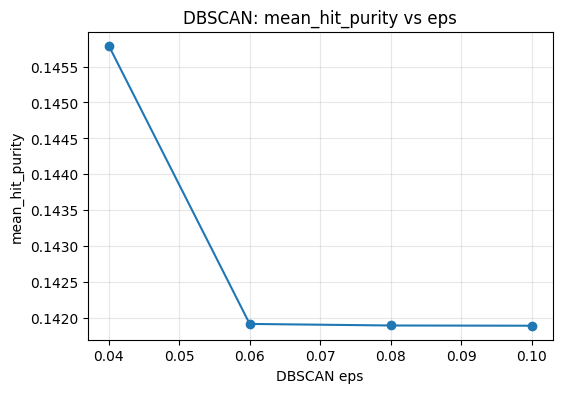

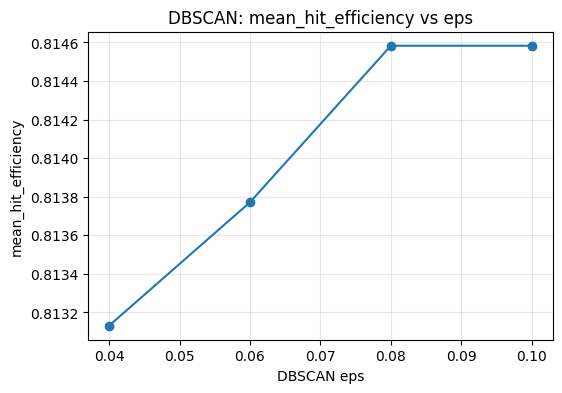

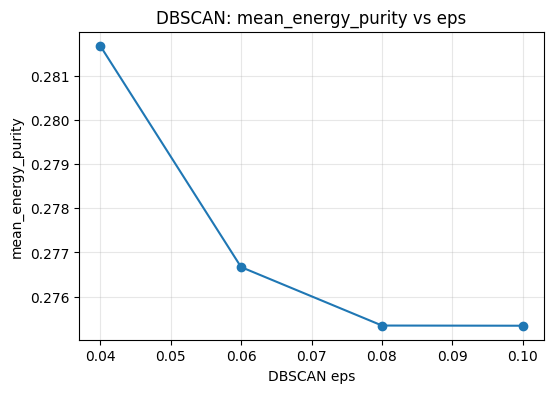

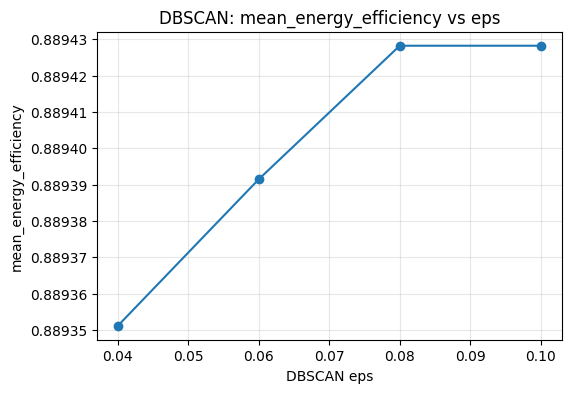

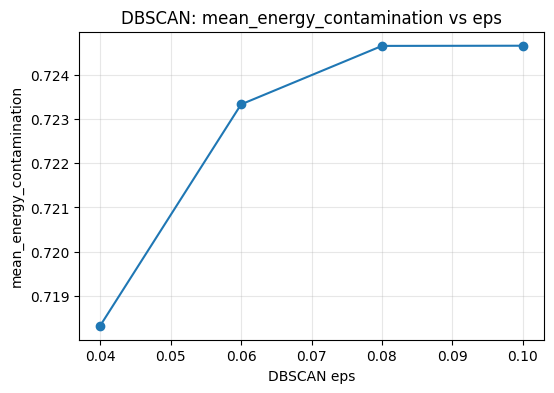

In [16]:
dbscan_summary = summary[summary["method"] == "dbscan"].sort_values("param")

metrics_to_plot = [
    "mean_hit_purity",
    "mean_hit_efficiency",
    "mean_energy_purity",
    "mean_energy_efficiency",
    "mean_energy_contamination",
]

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(
        dbscan_summary["param"],
        dbscan_summary[metric],
        marker="o",
    )

    ax.set_xlabel("DBSCAN eps")
    ax.set_ylabel(metric)
    ax.set_title(f"DBSCAN: {metric} vs eps")
    ax.grid(True, alpha=0.3)

    plt.show()

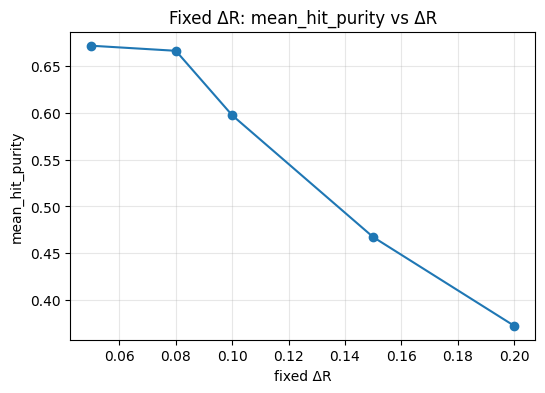

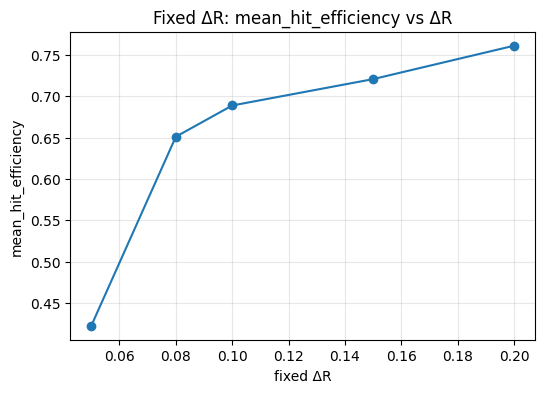

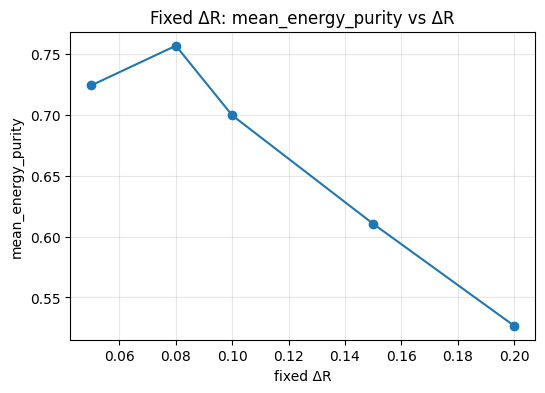

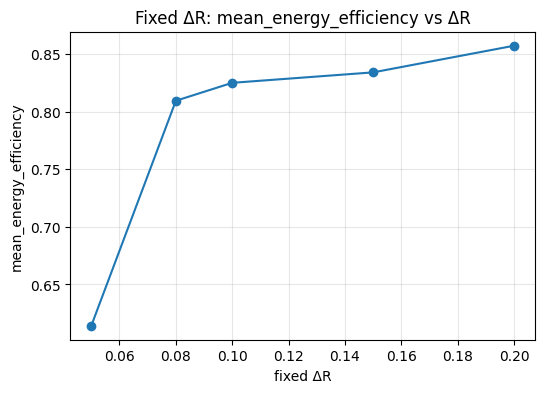

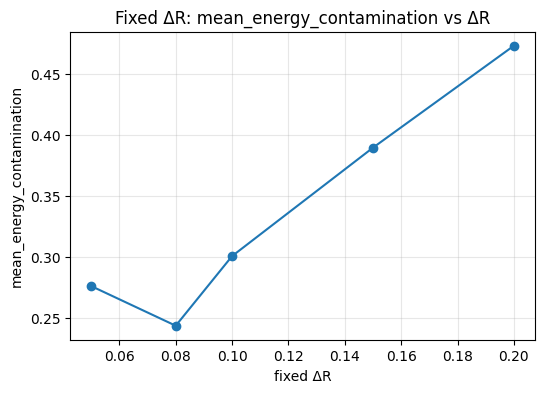

In [17]:
fixed_summary = summary[summary["method"] == "fixed_dR"].sort_values("param")

for metric in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(
        fixed_summary["param"],
        fixed_summary[metric],
        marker="o",
    )

    ax.set_xlabel("fixed ΔR")
    ax.set_ylabel(metric)
    ax.set_title(f"Fixed ΔR: {metric} vs ΔR")
    ax.grid(True, alpha=0.3)

    plt.show()

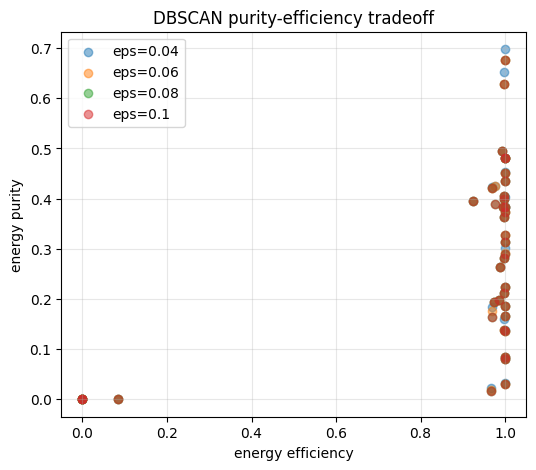

In [18]:
dbscan_matched = matched[matched["method"] == "dbscan"].copy()

fig, ax = plt.subplots(figsize=(6, 5))

for eps in sorted(dbscan_matched["eps"].dropna().unique()):
    sub = dbscan_matched[dbscan_matched["eps"] == eps]

    ax.scatter(
        sub["energy_efficiency"],
        sub["energy_purity"],
        alpha=0.5,
        label=f"eps={eps}",
    )

ax.set_xlabel("energy efficiency")
ax.set_ylabel("energy purity")
ax.set_title("DBSCAN purity-efficiency tradeoff")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

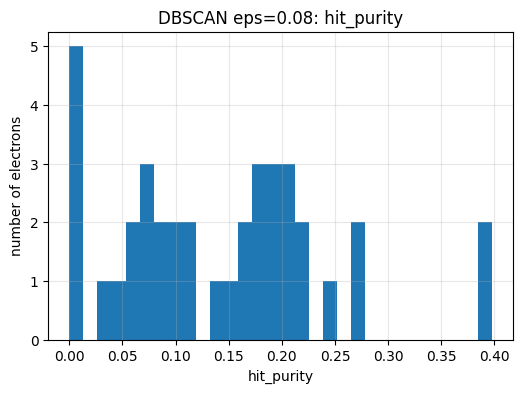

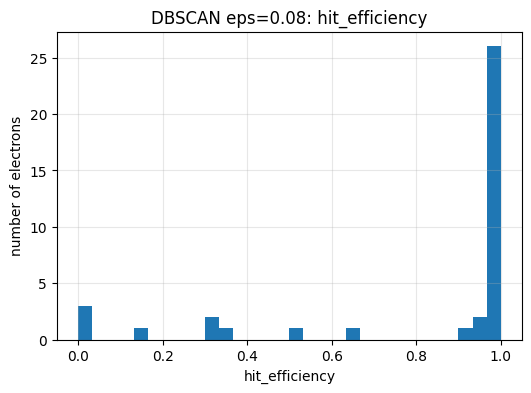

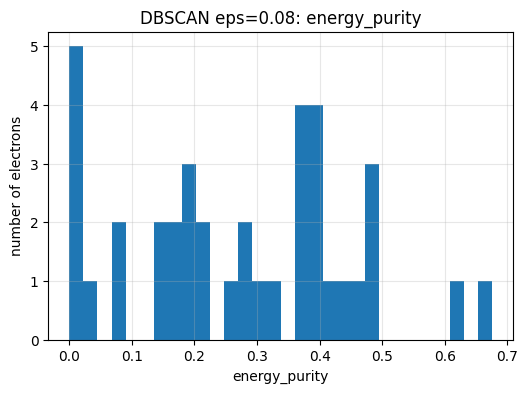

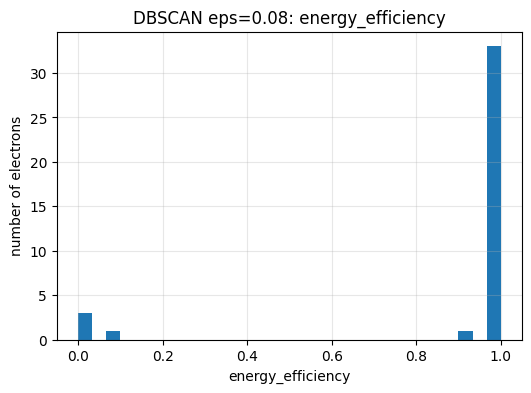

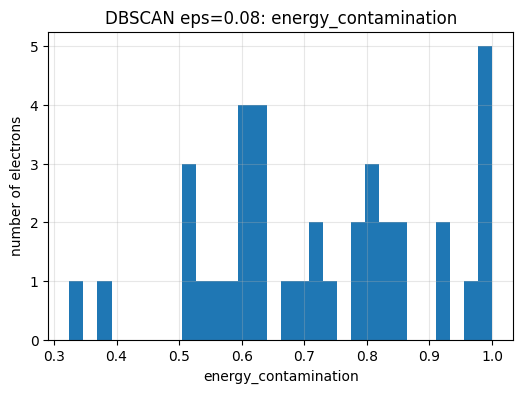

In [19]:
EPS_TO_INSPECT = 0.08

sub = matched[
    (matched["method"] == "dbscan") &
    (matched["eps"] == EPS_TO_INSPECT)
].copy()

hist_metrics = [
    "hit_purity",
    "hit_efficiency",
    "energy_purity",
    "energy_efficiency",
    "energy_contamination",
]

for metric in hist_metrics:
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.hist(sub[metric].dropna(), bins=30)

    ax.set_xlabel(metric)
    ax.set_ylabel("number of electrons")
    ax.set_title(f"DBSCAN eps={EPS_TO_INSPECT}: {metric}")
    ax.grid(True, alpha=0.3)

    plt.show()

In [20]:
for method in ["dbscan", "fixed_dR"]:
    print("\n" + "=" * 80)
    print(method)
    print("=" * 80)

    method_summary = summary[summary["method"] == method].sort_values("param")

    for _, row in method_summary.iterrows():
        print(f"\nparam = {row['param']}")
        print(f"  n electrons:                  {int(row['n_electrons'])}")
        print(f"  mean hit purity:              {row['mean_hit_purity']:.4f}")
        print(f"  mean hit contamination:       {row['mean_hit_contamination']:.4f}")
        print(f"  mean hit efficiency:          {row['mean_hit_efficiency']:.4f}")
        print(f"  mean energy purity:           {row['mean_energy_purity']:.4f}")
        print(f"  mean energy contamination:    {row['mean_energy_contamination']:.4f}")
        print(f"  mean energy efficiency:       {row['mean_energy_efficiency']:.4f}")


dbscan

param = 0.04
  n electrons:                  38
  mean hit purity:              0.1458
  mean hit contamination:       0.8542
  mean hit efficiency:          0.8131
  mean energy purity:           0.2817
  mean energy contamination:    0.7183
  mean energy efficiency:       0.8894

param = 0.06
  n electrons:                  38
  mean hit purity:              0.1419
  mean hit contamination:       0.8581
  mean hit efficiency:          0.8138
  mean energy purity:           0.2767
  mean energy contamination:    0.7233
  mean energy efficiency:       0.8894

param = 0.08
  n electrons:                  38
  mean hit purity:              0.1419
  mean hit contamination:       0.8581
  mean hit efficiency:          0.8146
  mean energy purity:           0.2753
  mean energy contamination:    0.7247
  mean energy efficiency:       0.8894

param = 0.1
  n electrons:                  38
  mean hit purity:              0.1419
  mean hit contamination:       0.8581
  mean hit effici

In [24]:
group_summary = (
    groups_df
    .groupby("eps")
    .agg(
        n_electrons=("particle_id", "count"),
        mean_n_clusters=("n_clusters", "mean"),
        median_n_clusters=("n_clusters", "median"),
        frac_one_cluster=("n_clusters", lambda s: np.mean(s == 1)),
        frac_multi_cluster=("n_clusters", lambda s: np.mean(s > 1)),
        frac_zero_cluster=("n_clusters", lambda s: np.mean(s == 0)),
        mean_noise_fraction=("noise_fraction", "mean"),
        mean_n_input_hits=("n_input_hits", "mean"),
        mean_largest_cluster_n_hits=("largest_cluster_n_hits", "mean"),
        mean_chosen_cluster_n_hits=("chosen_cluster_n_hits", "mean"),
        frac_chosen_is_largest=("chosen_is_largest", "mean"),
    )
    .reset_index()
    .sort_values("eps")
)

group_summary

,eps,n_electrons,mean_n_clusters,median_n_clusters,frac_one_cluster,frac_multi_cluster,frac_zero_cluster,mean_noise_fraction,mean_n_input_hits,mean_largest_cluster_n_hits,mean_chosen_cluster_n_hits,frac_chosen_is_largest
0,0.04,40,1.925,1.0,0.500,0.375,0.125,0.000252,3509.725,3475.175,3473.300,0.914286
1,0.06,40,1.225,1.0,0.725,0.150,0.125,0.000020,3509.725,3496.925,3493.850,0.942857
2,0.08,40,0.875,1.0,0.875,0.000,0.125,0.000000,3509.725,3509.725,3509.725,1.0
3,0.10,40,0.875,1.0,0.875,0.000,0.125,0.000000,3509.725,3509.725,3509.725,1.0
4,0.12,40,0.875,1.0,0.875,0.000,0.125,0.000000,3509.725,3509.725,3509.725,1.0


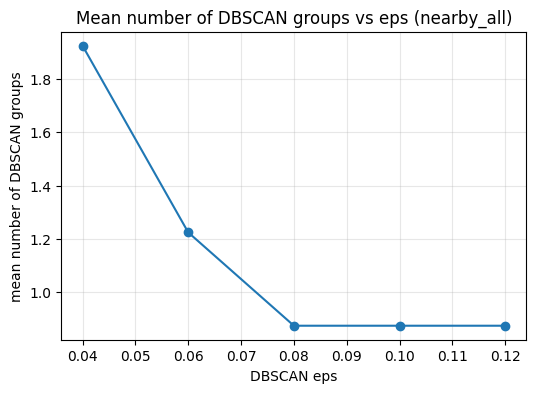

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    group_summary["eps"],
    group_summary["mean_n_clusters"],
    marker="o",
)

ax.set_xlabel("DBSCAN eps")
ax.set_ylabel("mean number of DBSCAN groups")
ax.set_title(f"Mean number of DBSCAN groups vs eps ({GROUP_INPUT_MODE})")
ax.grid(True, alpha=0.3)

plt.show()

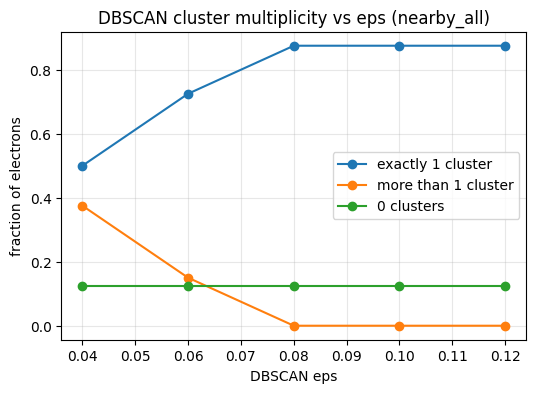

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    group_summary["eps"],
    group_summary["frac_one_cluster"],
    marker="o",
    label="exactly 1 cluster",
)

ax.plot(
    group_summary["eps"],
    group_summary["frac_multi_cluster"],
    marker="o",
    label="more than 1 cluster",
)

ax.plot(
    group_summary["eps"],
    group_summary["frac_zero_cluster"],
    marker="o",
    label="0 clusters",
)

ax.set_xlabel("DBSCAN eps")
ax.set_ylabel("fraction of electrons")
ax.set_title(f"DBSCAN cluster multiplicity vs eps ({GROUP_INPUT_MODE})")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

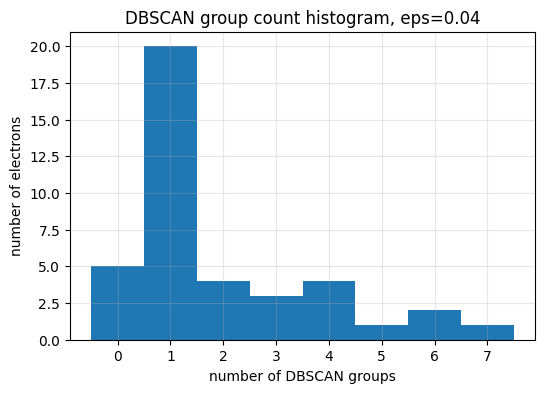

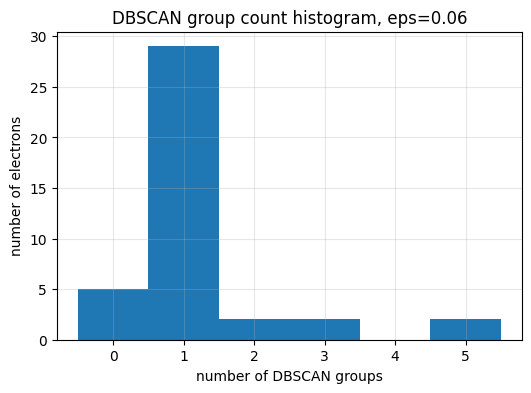

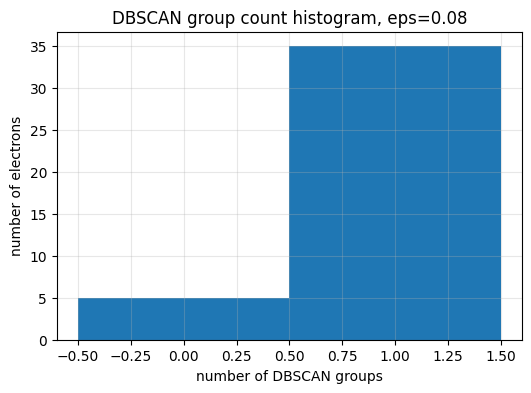

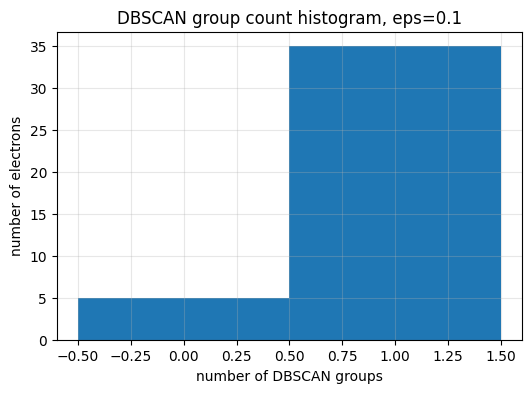

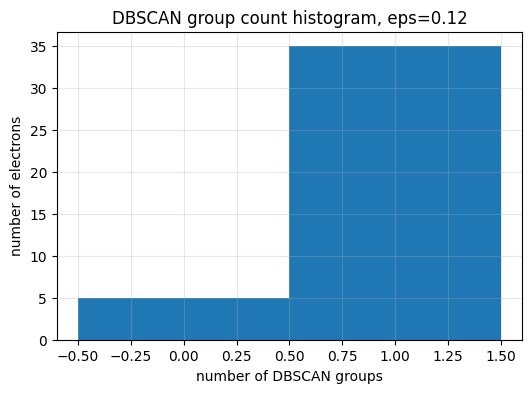

In [27]:
for eps in sorted(groups_df["eps"].unique()):
    sub = groups_df[groups_df["eps"] == eps]

    fig, ax = plt.subplots(figsize=(6, 4))

    bins = np.arange(sub["n_clusters"].min(), sub["n_clusters"].max() + 2) - 0.5

    ax.hist(sub["n_clusters"], bins=bins)

    ax.set_xlabel("number of DBSCAN groups")
    ax.set_ylabel("number of electrons")
    ax.set_title(f"DBSCAN group count histogram, eps={eps}")
    ax.grid(True, alpha=0.3)

    plt.show()

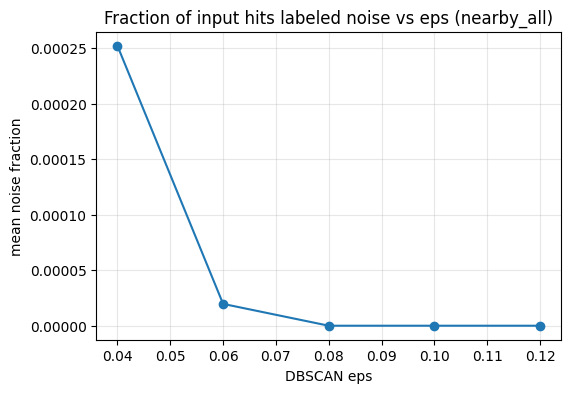

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    group_summary["eps"],
    group_summary["mean_noise_fraction"],
    marker="o",
)

ax.set_xlabel("DBSCAN eps")
ax.set_ylabel("mean noise fraction")
ax.set_title(f"Fraction of input hits labeled noise vs eps ({GROUP_INPUT_MODE})")
ax.grid(True, alpha=0.3)

plt.show()

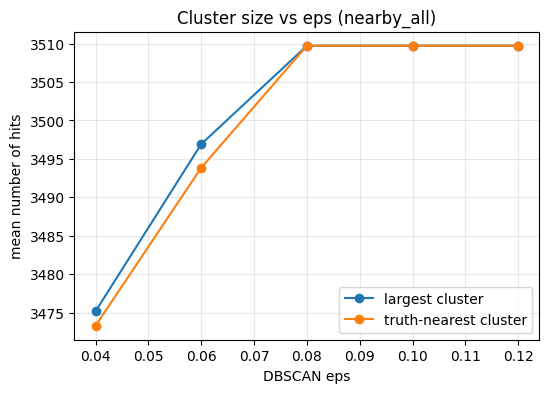

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    group_summary["eps"],
    group_summary["mean_largest_cluster_n_hits"],
    marker="o",
    label="largest cluster",
)

ax.plot(
    group_summary["eps"],
    group_summary["mean_chosen_cluster_n_hits"],
    marker="o",
    label="truth-nearest cluster",
)

ax.set_xlabel("DBSCAN eps")
ax.set_ylabel("mean number of hits")
ax.set_title(f"Cluster size vs eps ({GROUP_INPUT_MODE})")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()